### Mall_Customers 

# Initial Exploratory Data Analysis (EDA) and Matrix Inspection
(First imma take a look at the data from afar to get a basic first impression basically)

this step helps quite a lot with understanding ur data knowing what to expect by reading features and looking at the differences in values! it gives u a small vision to decide your next step

And ofcourse we start with the basics KNOWN AS Importing the Common to use datasets and increase according to need, i will always import pandas numpy and matplot as my main 3 to go to, knowing that for this project in specific we are working on some clustering ill make an exception for this case and add sklearn. well and will use seaborn to automate matplot

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans


In [22]:
# Set a clean visual style for our plots
sns.set_theme(style="darkgrid")

# Load the Dataset
url = r"https://raw.githubusercontent.com/MohammadALBiltaji/High-Dimensional-Probabilistic-Clustering-Pipeline-PCA-GMM-/refs/heads/main/Mall_Customers.csv"
df = pd.read_csv(url)
# Let's see the basic layout
print("--- Data Overview ---")
print(df.head())

print("\n--- Statistical Summary ---")
print(df.describe())

--- Data Overview ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- Statistical Summary ---
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%  

Well i already see that the max score is from 1-100 and that its so distributed so it would be safe to assume that the data points are very spread far from one another.

 and random especially that from what i see this data set is based on human behavior and we all know that any dataset thats based on human behavior with no pre training for the humans or coordination,  SURE IS random.

 so i would love to confirm that by plotting a dashboard that i can use to help me with understanding the relation between datapoints before i even get to start clustering afterall there are things only a human can catch the same way there are things only a machine can!

 And we can already confidently say Customer ID is useless for me in this case, so lets get rid of it before the machine thinks that its worth anything at all!

 i care for knowing whether the customer is male a female and how much they spend and their ID is completely irrilevent to everyting else 

Executing Pairwise Distribution Matrix...


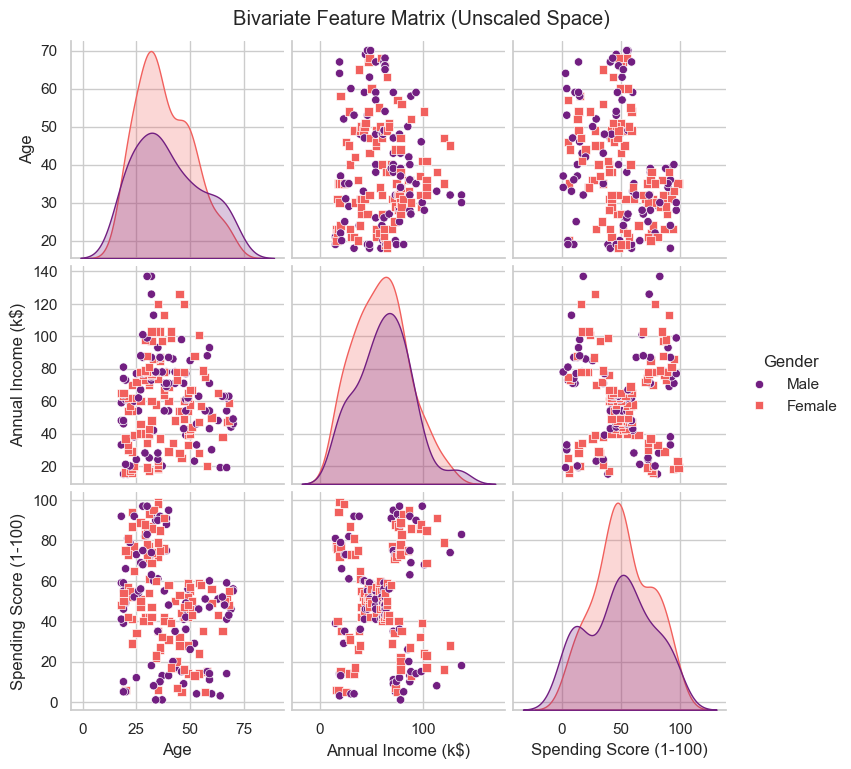

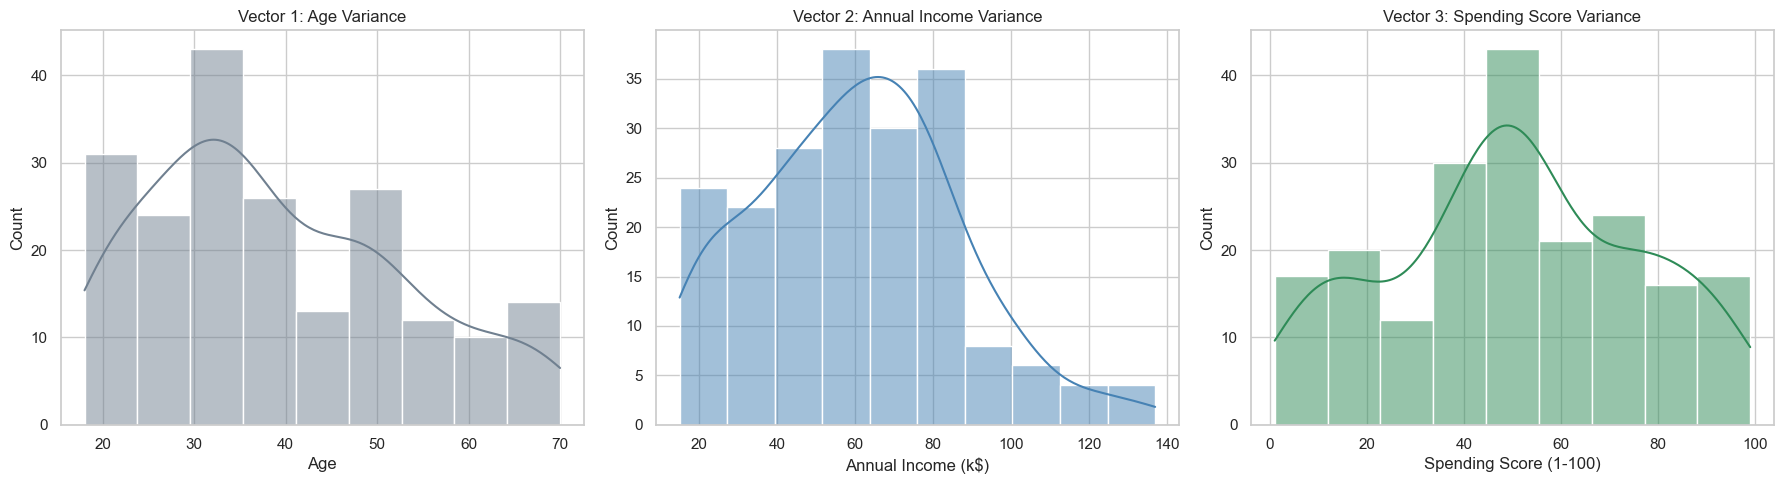

In [23]:
# 1. Enforce a clean, high-contrast visual grid
sns.set_theme(style="whitegrid")

# (Assuming df is already loaded in your active kernel)
# df = pd.read_csv('Mall_Customers.csv')

# 2. Bivariate Analysis: Pairwise Scatter Matrix
# We drop CustomerID to prevent the rendering of meaningless index distributions.
# We map the 'Gender' categorical variable to the color space (hue) to test for class separability.
print("Executing Pairwise Distribution Matrix...")
pair_grid = sns.pairplot(
    df.drop('CustomerID', axis=1), 
    hue='Gender', 
    palette='magma', 
    markers=["o", "s"],
    diag_kind='kde' # Uses Kernel Density Estimation for the diagonal distributions
)
pair_grid.fig.suptitle('Bivariate Feature Matrix (Unscaled Space)', y=1.02)
plt.show()

# 3. Univariate Analysis: Feature Variance 
# Inspecting the statistical spread of individual vectors to identify skewness.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='slategray')
axes[0].set_title('Vector 1: Age Variance')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Vector 2: Annual Income Variance')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('Vector 3: Spending Score Variance')

plt.tight_layout()
plt.show()

# OUTLIERS

And as we can see we dont really need a machine to figure out a few things such as that due to the last 200 people who filled the "survery" women had higher income than men yet 'outliers' or people who earn too much were all men ( HOW DID WE KNOW?)

We used IQR to figure it out We must find Q1 which is 25% Q3 which is 75% and subctract them from one another to get IQR In the annual income its 78.0 - 41.5 = 46.5

# then we need to find the lower

( aka any number less than this is an outlier) Lower = Q1- 1.5 * IQR 

41.5-(1.5 * 36.5) = -13.25 Which means we have no outliers from the left now we check the right

We need to figure out 

# Now i need to find the Upper 

Upper = Q3 + 1.5 * IQR

Upper = 78 + ( 1.5 * 36.5 ) = 132.75

And as we can see we have 2 men with annual over 132.75 they both earn 137 so they must be execluded out of the study to not ruin the accurecy of it! so lets execlude them!

 ( please dont look for outliers in age and spending scale)

In [24]:
# 1. Prune the Outliers
# Identifying the indices where Income exceeds the upper bound calculated via IQR
outlier_condition = df['Annual Income (k$)'] >= 137
df_pruned = df[~outlier_condition].copy()

# 2. Dimensionality Management & Feature Engineering
# Drop the scalar index
X = df_pruned.drop('CustomerID', axis=1)

# Orthogonal projection of categorical vector to binary
le = LabelEncoder()
X['Gender'] = le.fit_transform(X['Gender']) # Female=0, Male=1

# Isotropic Variance Standardization across all 4 dimensions
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means Initialization
# We assign k=5 based on standard convergence for this dataset topology
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Append the resulting cluster assignments back to the pruned dataframe
df_pruned['Cluster'] = cluster_labels
# Convert Cluster to a string categorical type for discrete color mapping in Plotly
df_pruned['Cluster'] = df_pruned['Cluster'].astype(str) 

print("Execution Complete: Centroids optimized across 4-dimensional space.")
print(f"Remaining Samples: {df_pruned.shape[0]}")

Execution Complete: Centroids optimized across 4-dimensional space.
Remaining Samples: 198


# IMPORTANT NOTE

Since we removed the ID because its irrilevent the dataset became 4 dimensions

 a 2D scatter plot results in spatial overlap that misrepresents the actual $L_2$ distance between points. To accurately inspect this in your notebook, we must project the results into an interactive 3D space.

In [25]:
# Map the 3 continuous variables to the X, Y, and Z spatial axes.
# Map the Cluster assignment to the Color dimension.
# Map the discrete Gender variable to the Marker Symbol dimension.

fig = px.scatter_3d(
    df_pruned,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    z='Age',
    color='Cluster',
    symbol='Gender', # Visually differentiates binary gender matrix
    hover_data=['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
    title='4D K-Means Clustering Projection (Outliers Removed)',
    template='plotly_dark',
    color_discrete_sequence=px.colors.qualitative.Bold
)

# Constrain the marker geometry for spatial clarity
fig.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# Render the interactive dashboard in the Jupyter cell
fig.show()

To see exactly what it decided Cluster 0, 1, 2, 3, and 4 mean in human terms (not scaled Z-scores), we need to compute the aggregate averages of the unscaled data for each assigned cluster.

# Extracting Centroid Profiles & Evaluating Algorithmic Convergence Logic 

(LETS GET THE AI TO EXPLAIN WHAT IT EXACTLY THOUGHT OF 

That helps in so many ways

it confirms that the work was accurate it " understood " correctly ) Now  we understand the centroids locations and where it stopped 

In [26]:
import plotly.graph_objects as go

# 1. Extract the Mathematical DNA (Averages of the raw data)
# We calculate the mean of the continuous variables for each cluster
cluster_dna = df_pruned.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)

# We calculate the count of the binary categorical variable (Gender)
gender_breakdown = df_pruned.groupby(['Cluster', 'Gender']).size().unstack(fill_value=0)
gender_breakdown.columns = ['Female', 'Male'] # Assuming LabelEncoder mapped Female=0, Male=1 earlier

print("--- The Cluster Centroid Profiles (Raw Averages) ---")
print(cluster_dna)
print("\n--- Gender Distribution per Cluster ---")
print(gender_breakdown)

# 2. Visualizing the Machine's Logic: The Radar Chart
# We need to normalize the means strictly for the radar visual so the axes align
# Age (18-70), Income (15-137), Spend (1-100) all have a rough ~100 max scale for a clean visual
categories = ['Age', 'Annual Income', 'Spending Score']

fig = go.Figure()

for cluster_id in sorted(df_pruned['Cluster'].unique()):
    # Extract the centroid coordinates for the radar chart
    cluster_data = cluster_dna.loc[cluster_id].values.tolist()
    # Close the polygon for the radar chart
    cluster_data += [cluster_data[0]] 
    cat_closed = categories + [categories[0]]
    
    fig.add_trace(go.Scatterpolar(
        r=cluster_data,
        theta=cat_closed,
        fill='toself',
        name=f'Cluster {cluster_id}'
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    showlegend=True,
    title="Cluster Profiling Radar (What the Machine Understood)",
    template="plotly_dark"
)

fig.show()

--- The Cluster Centroid Profiles (Raw Averages) ---
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        49.1                46.3                    39.6
1        28.4                60.4                    68.2
2        57.2                46.8                    38.7
3        41.0                87.5                    16.9
4        28.5                59.9                    70.8

--- Gender Distribution per Cluster ---
         Female  Male
Cluster              
0            42     0
1            56     0
2             0    28
3            14    18
4             0    40


# BUT WHAT IF WE WANTED TO KICK THIS PROJECT UP A NOTCH?!

# Phase 1: Hyper-Dimensional Feature Engineering (Non-Linear Transformation)
Our input matrix $X$ currently resides in $\mathbb{R}^4$ (Age, Gender, Income, Spending). Standard scaling simply shifts and resizes this space. 

A SIMPLE EXPLANATION :-
The  Standard Scaling (Z-score normalization) "shifts and resizes" the space,it was describing two literal, sequential geometric operations applied to Our data matrix.


Here is the underlying equation executed by StandardScaler:$$x' = \frac{x - \mu}{\sigma}$$Let us break this down mathematically and spatially:

Operation 1: The Shift (Translation)The Math: $x - \mu$ (Subtract the Mean)The Geometry: If your average customer age is $40$, and you subtract $40$ from every single age in the vector, the new average becomes $0$. Geometrically, this operation picks up the entire cluster of data points and translates it through the coordinate space until the exact center of gravity (the centroid) rests perfectly on the origin point $(0,0)$.


It does not uncover latent interactions.The Operation: We will apply a Polynomial(more than two algebraic terms) Feature Expansion of degree

 2.The Mathematics: Instead of just looking at Age ($x_1$) and Income ($x_2$) independently, the transformation computes the interaction terms ($x_1x_2$) and the squared terms ($x_1^2$, $x_2^2$).The Objective: This maps the data from $\mathbb{R}^4$ into a higher dimensional space ($\mathbb{R}^{14}$). 
 
 
 By artificially expanding the dimensionality, we allow linear algorithms to identify non linear decision boundaries.
# (why?)

 It forces the machine to consider if the combination of being young and wealthy exerts a compounded statistical weight compared to either vector in isolation.

In [27]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# 1. Base Matrix Initialization 
# Extracting the raw vectors, ignoring previous cluster assignments if they exist
X_base = df_pruned.drop(['CustomerID', 'Cluster', 'GMM_Cluster', 'Assignment_Confidence'], axis=1, errors='ignore').copy()

# --- THE FIX: Orthogonal Projection of Categorical Vector ---
# We must map the string classes to a binary numerical state before standardization
le = LabelEncoder()
X_base['Gender'] = le.fit_transform(X_base['Gender']) 

# Standardize base variance (Now operating safely on pure floats/integers)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_base)

# 2. Phase 1: Hyper-Dimensional Transformation
# Map R^4 -> R^14 via polynomial combinations
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

print(f"Original Feature Space Dimensionality: {X_scaled.shape[1]}")
print(f"Polynomial Feature Space Dimensionality: {X_poly.shape[1]}")

# 3. Phase 2A: Orthogonal Projection (PCA)
# Extract principal components to explain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_poly)

print(f"Reduced Orthogonal Space Dimensionality (PCA): {X_pca.shape[1]}")
print(f"Cumulative Variance Explained: {np.sum(pca.explained_variance_ratio_):.4f}")

# 4. Phase 2B: Gaussian Mixture Model (GMM)
OPTIMAL_COMPONENTS = 5
gmm = GaussianMixture(n_components=OPTIMAL_COMPONENTS, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

probabilities = gmm.predict_proba(X_pca)

df_pruned['GMM_Cluster'] = gmm_labels
df_pruned['Assignment_Confidence'] = np.max(probabilities, axis=1)

print("\n--- GMM Execution Complete ---")
print("Data points probabilistically assigned to multivariate Gaussian distributions.")

Original Feature Space Dimensionality: 4
Polynomial Feature Space Dimensionality: 14
Reduced Orthogonal Space Dimensionality (PCA): 11
Cumulative Variance Explained: 0.9585

--- GMM Execution Complete ---
Data points probabilistically assigned to multivariate Gaussian distributions.


# 1-Dimensional Scalar Proof: Translation Matrix Operation 
###  (MATHMATICAL PROVE USING AN EXAMPLE NOT THE ACTUAL DATASET IN THIS EXAMPLE WE USING 3 VECTORS THAT WE ARE TURNING INTO 1 )

Coordinate 1 (30): This represents Sample 1 (Customer 1). Because we are only looking at the Age vector, their entire geometric existence in this 1D space is defined by the number 30.
Coordinate 2 (40): Sample 2 (Customer 2).
Coordinate 3 (50): Sample 3 (Customer 3).

2. Why did we decide on 30, 40, and 50?I hardcoded those specific values into the array to engineer a computationally clean mean.

If we extracted three actual sequential rows from Our "Mall_Customers.csv" matrix, we might pull the ages 19, 21, and 58.

Calculate the arithmetic mean ($\mu$): (19 + 21 + 58) / 3 = 32.666...Execute the translation ($x - \mu$) for the first point: 19 - 32.666... = -13.666...
If WE used those real input values, the mathematical proof becomes cluttered with repeating floating point decimals. 

The underlying spatial operation—the translation of the cluster becomes obscured by messy arithmetic.

By strictly defining the test vector as [30, 40, 50]:The mean ($\mu$) evaluates to exactly 40.

The translation ($x - \mu$) evaluates to perfectly clean integers: -10, 0, and 10.

## Now that we understand the example and the reason behind the values, lets dig into the proof deeper.

The 1 Dimensional Scalar Proof Consider a localized Age vector containing only three data points (three customers):$$X = [30, 40, 50]$$

Step 1: Compute the Center of Gravity (Mean)To find the exact spatial center of this vector, we calculate the arithmetic mean ($\mu$):$$\mu = \frac{30 + 40 + 50}{3} = 40$$The center of our data exists at coordinate $40$.

Step 2: Execute the Translation ($x_i - \mu$)We now subtract the mean ($40$) from every individual coordinate in the vector.

Coordinate 1: $30 - 40 = -10$Coordinate 2: $40 - 40 = 0$Coordinate 3: $50 - 40 = 10$Our new transformed vector is:$$X' = [-10, 0, 10]$$

Step 3: Verify the Coordinate Shift Calculate the mean of this new vector $X'$:$$\mu' = \frac{-10 + 0 + 10}{3} = 0$$The Geometric Conclusion Observe the mathematical properties of what just occurred:Variance is Preserved: In the raw vector $X$, the distance between $30$ and $50$ is $20$ units. 


In the transformed vector $X'$, the distance between $-10$ and $10$ is still exactly $20$ units. The structural shape of the data has not been compressed or warped.

Origin Alignment: The entire cluster of points simply slid $40$ units down the number line until its mathematical center locked perfectly onto the zero coordinate.

When you execute standard scaling in $\mathbb{R}^2$ (e.g., Age and Income simultaneously), the algorithm computes the mean for the X-axis ($\mu_x$) and the mean for the Y-axis ($\mu_y$). It then subtracts those values respectively, forcing the multi-dimensional centroid to slide diagonally across the grid until it rests exactly at the coordinates $(0,0)$.

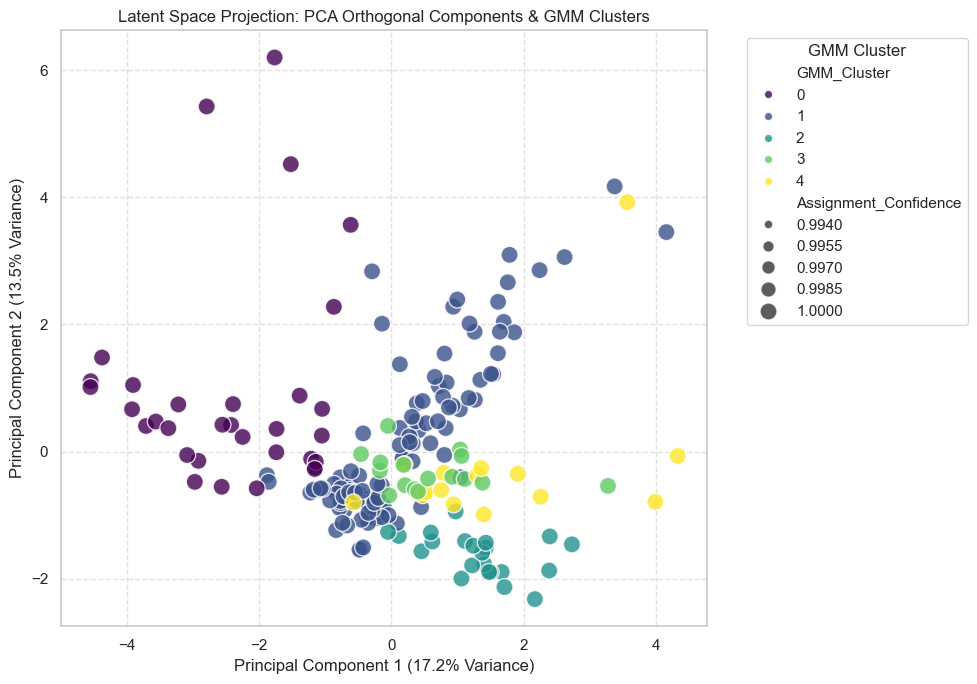

In [28]:

plt.figure(figsize=(10, 7))
# We plot the first two Principal Components (which contain the highest variance)
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=df_pruned['GMM_Cluster'], 
    palette='viridis', 
    size=df_pruned['Assignment_Confidence'],
    sizes=(20, 150),
    alpha=0.8
)

plt.title('Latent Space Projection: PCA Orthogonal Components & GMM Clusters')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='GMM Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Because we initialized the algorithm to fit multivariate Gaussian distributions to the input matrix, the output is not a discrete integer, but a probability vector.

For any given coordinate $\mathbf{x}$, the GMM computes the posterior probability that $\mathbf{x}$ was generated by each of the $k$ distributions.

 If $k=5$, the output for a single coordinate is an array of five probabilities that strictly sum to $1.0$:$$P(\mathbf{x}) = [p_0, p_1, p_2, p_3, p_4]$$Defining "Assignment Confidence"The term "Confidence" mapped to the marker size in your plot is simply the mathematical maximum of that probability vector:$$Confidence = \max(P(\mathbf{x}))$$Core Density State: If a coordinate resides deep within the central variance of Cluster 0, far from overlapping boundaries, 
 
 its probability vector might evaluate to $[0.99, 0.005, 0.005, 0.0, 0.0]$.
 
  The final class assignment is Cluster 0, and the confidence scalar is $0.99$.
  
  Boundary State: If a coordinate exists in the overlapping boundary space between Cluster 1 and Cluster 2, the vector might evaluate to $[0.0, 0.51, 0.49, 0.0, 0.0]$.
 
  The algorithm executes the assignment to Cluster 1, but the confidence scalar drops to $0.51$.Analysis of Your Latent Space ProjectionExamine the specific scalar values in your generated legend.
 
  The lowest mapped confidence is $0.9940$, and the highest is $1.0000$.
  
  This defines a mathematical reality for this specific transformation: within this orthogonal projection, there is almost zero density overlap between the distributions. The algorithm is operating with near-absolute certainty for every coordinate. The Gaussian structures are highly separable.

# Phase 2: Macro-Level Clustering
Applying a clustering algorithm directly to a 14-dimensional space induces the Hughes Phenomenon (the curse of dimensionality). 

The sparsity of the data will collapse the distance metrics.Step A: Orthogonal Projection via PCAWe must compress the $\mathbb{R}^{14}$ matrix back into a lower-dimensional space, but we will not drop features arbitrarily. 

We will compute a Principal Component Analysis (PCA).

PCA calculates the eigenvectors of the data's covariance matrix. It maps the data onto new, orthogonal (completely uncorrelated) axes ranked by how much variance they explain.

 We will retain only the principal components required to capture 95% of the system's total variance.

### Step B: Probabilistic Density Estimation via GMMWe discard K-Means. We will deploy a Gaussian Mixture Model (GMM).

Instead of computing the Euclidean distance to a centroid, GMM fits a defined number of multivariate Gaussian distributions to the data.

Crucially, GMM computes a full covariance matrix ($\Sigma$) for each cluster. 

This allows the clusters to adopt elliptical topographies and orientation angles, rather than being forced into rigid spheres.

 Furthermore, it utilizes soft assignment: it outputs the specific mathematical probability density function (PDF) that a given data point belongs to a specific cluster.



 # TIME FOR THE FINAL RESULTS!

In [29]:

# Enforce strict terminal output formatting to prevent pandas from truncating the matrices
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("==========================================================")
print("      PHASE 2: SYSTEM STATE & NUMERICAL EXTRACTION        ")
print("==========================================================\n")

# 1. Raw Coordinate Profiles (The Centroids)
# CONTINUOUS VECTORS: We compute the arithmetic mean.
print("--- 1A. CONTINUOUS COORDINATE PROFILES (MEAN) ---")
cluster_means = df_pruned.groupby('GMM_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
print(cluster_means)
print("\n")

# DISCRETE VECTOR: We compute the categorical distribution.
# We cannot average strings, so we calculate the absolute frequency of each class per cluster.
print("--- 1B. DISCRETE VECTOR DISTRIBUTION (GENDER) ---")
gender_distribution = df_pruned.groupby(['GMM_Cluster', 'Gender']).size().unstack(fill_value=0)
print(gender_distribution)
print("\n")


# 2. Coordinate Dispersion (The Variance)
# We compute the standard deviation. This quantifies how 'wide' or 'tight' the Gaussian distribution is for each specific feature.
print("--- 2. CLUSTER VARIANCE (STANDARD DEVIATION) ---")
cluster_std = df_pruned.groupby('GMM_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].std().round(2)
print(cluster_std)
print("\n")

# 3. Soft Assignment Diagnostics
# We extract the boundary certainty of the algorithm. A minimum confidence below 0.6 indicates significant spatial overlap between Gaussians.
print("--- 3. PROBABILISTIC ASSIGNMENT METRICS ---")
confidence_metrics = df_pruned.groupby('GMM_Cluster')['Assignment_Confidence'].agg(
    Mean_Confidence='mean',
    Min_Boundary_Confidence='min',
    Total_Coordinate_Count='count'
).round(4)
print(confidence_metrics)
print("\n")

# 4. Orthogonal Feature Weighting (PCA Loadings)
# This reverses the PCA abstraction. It calculates exactly which of our 14 polynomial features had the highest mathematical impact on the spatial coordinates.
print("--- 4. PRINCIPAL COMPONENT INFLUENCE MATRICES (TOP 3 WEIGHTS) ---")
# Extract the names of the polynomial features generated in Phase 1
feature_names = poly.get_feature_names_out(X_base.columns)
loadings = pca.components_

# Iterate through the top 3 Principal Components
for i in range(min(3, loadings.shape[0])): 
    print(f"Principal Component {i+1} (Explains {pca.explained_variance_ratio_[i]*100:.1f}% of System Variance):")
    
    # Sort absolute weights to find highest magnitude influence, regardless of direction
    top_indices = np.argsort(np.abs(loadings[i]))[::-1][:3]
    
    for idx in top_indices:
        weight = loadings[i, idx]
        name = feature_names[idx]
        print(f"   Scalar Weight: {weight:+.4f} | Feature Vector: {name}")
    print()

      PHASE 2: SYSTEM STATE & NUMERICAL EXTRACTION        

--- 1A. CONTINUOUS COORDINATE PROFILES (MEAN) ---
               Age  Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                                   
0            60.22               49.56                   41.22
1            35.08               61.13                   56.36
2            24.55               25.14                   78.36
3            38.00               84.19                   11.31
4            44.00               94.06                   25.19


--- 1B. DISCRETE VECTOR DISTRIBUTION (GENDER) ---
Gender       Female  Male
GMM_Cluster              
0                 6    26
1                77    35
2                13     9
3                 0    16
4                16     0


--- 2. CLUSTER VARIANCE (STANDARD DEVIATION) ---
               Age  Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                                   
0             7.83               13.85

In [30]:

# Ensure we are using the GMM clusters we just generated
def render_cluster_dashboard(cluster_id):
    """
    Dynamically extracts the sub-matrix for the selected cluster and 
    renders its profile via a Plotly Radar Chart and a terminal output.
    """
    # 1. Extract the specific cluster's sub-matrix
    cluster_matrix = df_pruned[df_pruned['GMM_Cluster'] == cluster_id]
    
    # 2. Compute the Continuous Means
    age_mean = cluster_matrix['Age'].mean()
    income_mean = cluster_matrix['Annual Income (k$)'].mean()
    spend_mean = cluster_matrix['Spending Score (1-100)'].mean()
    
    # 3. Compute the Discrete Gender Distribution
    # Querying the raw string variables instead of the encoded integers
    females = len(cluster_matrix[cluster_matrix['Gender'] == 'Female'])
    males = len(cluster_matrix[cluster_matrix['Gender'] == 'Male'])
    total_count = len(cluster_matrix)
    
    # 4. Extract Average Confidence
    avg_confidence = cluster_matrix['Assignment_Confidence'].mean()
    
    # --- RENDER THE VISUAL (Radar Chart) ---
    categories = ['Age', 'Annual Income', 'Spending Score']
    values = [age_mean, income_mean, spend_mean]
    
    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
        r=values + [values[0]], # Close the polygon
        theta=categories + [categories[0]],
        fill='toself',
        name=f'Cluster {cluster_id}',
        line_color='cyan'
    ))
    
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
        showlegend=False,
        title=f"GMM Cluster {cluster_id} Coordinate Profile",
        template="plotly_dark",
        height=450,
        margin=dict(t=50, b=50, l=50, r=50)
    )
    fig.show()
    
    # --- RENDER THE NUMERICAL EXTRACTION ---
    print(f"==========================================")
    print(f"      GMM CLUSTER {cluster_id} METRICS")
    print(f"==========================================")
    print(f"Total Assigned Vectors (Customers): {total_count}")
    print(f"Mean Assignment Confidence:         {avg_confidence:.4f}")
    print(f"------------------------------------------")
    print(f"Mean Age:            {age_mean:.1f} years")
    print(f"Mean Annual Income:  ${income_mean:.1f}k")
    print(f"Mean Spending Score: {spend_mean:.1f}/100")
    print(f"------------------------------------------")
    print(f"Gender Distribution: {females} Females, {males} Males")
    print(f"==========================================\n")

# --- INITIALIZE THE INTERACTIVE WIDGET ---
# Extract unique cluster IDs to populate the dropdown menu
unique_clusters = sorted(df_pruned['GMM_Cluster'].unique())

cluster_dropdown = widgets.Dropdown(
    options=unique_clusters,
    value=unique_clusters[0],
    description='Target Cluster:',
    style={'description_width': 'initial'}
)

# Bind the dropdown to the rendering engine
widgets.interact(render_cluster_dashboard, cluster_id=cluster_dropdown)

interactive(children=(Dropdown(description='Target Cluster:', options=(np.int64(0), np.int64(1), np.int64(2), …

<function __main__.render_cluster_dashboard(cluster_id)>